# The Order-2.0 Weak Taylor Scheme vs. Weak Euler

A worked comparison of *weak* convergence order for geometric Brownian motion: the weak Euler
scheme (order $\beta=1.0$) against the order-$\beta=2.0$ weak Taylor scheme of Milstein (1978) /
Talay (1984), measuring the error in $\mathbb E[X_T]$ rather than a pathwise quantity.

## Problem

On a filtered probability space $(\Omega,\mathcal F,(\mathcal F_t),P)$ carrying a standard Wiener
process $(W_t)$, consider geometric Brownian motion

$$
dX_t = aX_t\,dt + bX_t\,dW_t, \qquad X_0 = x_0 > 0,
$$

with $a=1.5$, $b=0.01$, $x_0=0.1$, $T=1$ (Kloeden & Platen, PC-Exercise 14.2.2). Since
$\mathbb E[\exp(\sigma W_t-\tfrac12\sigma^2 t)]=1$ for any $\sigma$, taking expectations of the
closed-form solution $X_t = x_0\exp\{(a-\tfrac12b^2)t+bW_t\}$ gives the exact, closed-form target

$$
\mathbb E[X_T] = x_0 e^{aT},
$$

independent of $b$. This is the functional $\mathbb E[g(X_T)]$, $g(x)=x$, whose approximation error
$\big|\mathbb E[g(X_T)] - \mathbb E[g(Y_N)]\big|$ defines *weak* convergence — a fundamentally
weaker (and, for pricing, more relevant) requirement than the *strong* (pathwise, $L^1$/$L^2$)
convergence studied in the other notebooks of this folder.

## Method

**Weak Euler** (Kloeden & Platen, eq. 14.1.1): $Y_{n+1} = Y_n + a(Y_n)\Delta + b(Y_n)\Delta W_n$ —
algebraically identical to the strong Euler-Maruyama recursion; only the *criterion* used to judge
its accuracy differs. Talay (1984) shows this has weak order $\beta=1.0$ under four-times
differentiability of $a,b$ with a growth bound, in contrast to the strong Euler scheme's order
$\gamma=0.5$ — an entire order of convergence is "free" once only a functional of the law, rather
than the path itself, is required.

**Order-2.0 weak Taylor scheme** (Kloeden & Platen, eq. 14.2.1, after Milstein 1978 / Talay 1984):

$$
Y_{n+1} = Y_n + a\Delta + b\Delta W_n + \tfrac12 bb'\big[(\Delta W_n)^2-\Delta\big]
             + ba'\,\Delta Z_n + \tfrac12\Big[aa' + \tfrac12 b^2a''\Big]\Delta^2,
$$

where $\Delta Z_n := \int_{t_n}^{t_n+\Delta}(W_s-W_{t_n})\,ds$ is the *time-space* Lévy area of a
single Wiener process against time. This is the same auxiliary variable used in the strong
order-1.5 Taylor scheme; unlike the multidimensional Lévy area studied elsewhere in this folder, it
requires no separate approximation, because $(\Delta W_n,\Delta Z_n)$ is **exactly** jointly
Gaussian. Writing $\Delta Z_n=\int_0^\Delta W_s\,ds$ (WLOG $t_n=0$) and using
$\operatorname{Cov}(\Delta W,W_s)=s$ gives directly

$$
\mathbb E[\Delta Z_n]=0,\qquad
\mathbb E[\Delta Z_n^2]=\int_0^\Delta\!\!\int_0^\Delta \min(s,u)\,ds\,du=\tfrac13\Delta^3,\qquad
\operatorname{Cov}(\Delta W_n,\Delta Z_n)=\int_0^\Delta s\,ds=\tfrac12\Delta^2.
$$

Conditioning on $\Delta W_n$ and matching the residual variance
$\operatorname{Var}(\Delta Z_n\mid\Delta W_n)=\tfrac13\Delta^3-\tfrac14\Delta^3=\tfrac1{12}\Delta^3$
gives the exact sampler used below:

$$
\Delta Z_n = \tfrac12\Delta\Big(\Delta W_n + \tfrac1{\sqrt3}\Delta\widetilde W_n\Big),
\qquad \Delta\widetilde W_n \sim N(0,\Delta)\ \text{independent of }\Delta W_n.
$$

For $a(x)=ax$, $b(x)=bx$ (so $a'=a$, $b'=b$, $a''=0$), the scheme collapses to the closed
multiplicative update

$$
Y_{n+1} = Y_n\Big[1 + a\Delta + b\Delta W_n + \tfrac12 b^2\big((\Delta W_n)^2-\Delta\big)
             + ab\,\Delta Z_n + \tfrac12 a^2\Delta^2\Big].
$$

Both schemes are simulated with exact $N(0,\Delta)$ Gaussian increments (no need for the simplified
two-/three-point discrete random variables Kloeden & Platen use for hand computation — matching
low-order moments exactly is the only requirement for weak convergence, and an exact Gaussian
trivially does so to all orders). The weak error $\big|\mathbb E[X_T]-\widehat{\mathbb E}[Y_N]\big|$
is estimated by a Monte Carlo average over a large, independent, fresh batch of paths at each
step size — deliberately *not* the common-random-number / path-refinement construction used for
strong-error studies elsewhere in this repo, since weak error concerns the law of $Y_N$, not its
coupling to any particular realization of $X$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260720)

a, b, x0, T = 1.5, 0.01, 0.1, 1.0
exact_mean = x0 * np.exp(a * T)
print(f"Exact E[X_T] = x0 * exp(a*T) = {exact_mean:.10f}")

n_paths = 1_000_000
deltas = [2.0**-k for k in range(4, 9)]    # 2^-4, ..., 2^-8


def weak_euler_mean(Delta, n_paths, rng):
    n_steps = int(round(T / Delta))
    Y = np.full(n_paths, x0)
    for _ in range(n_steps):
        dW = rng.normal(0.0, np.sqrt(Delta), size=n_paths)
        Y = Y * (1.0 + a * Delta + b * dW)
    return Y.mean()


def weak_taylor2_mean(Delta, n_paths, rng):
    n_steps = int(round(T / Delta))
    Y = np.full(n_paths, x0)
    for _ in range(n_steps):
        dW = rng.normal(0.0, np.sqrt(Delta), size=n_paths)
        dW_tilde = rng.normal(0.0, np.sqrt(Delta), size=n_paths)
        dZ = 0.5 * Delta * (dW + dW_tilde / np.sqrt(3.0))
        factor = (1.0 + a * Delta + b * dW
                  + 0.5 * b * b * (dW * dW - Delta)
                  + a * b * dZ
                  + 0.5 * a * a * Delta * Delta)
        Y = Y * factor
    return Y.mean()


Exact E[X_T] = x0 * exp(a*T) = 0.4481689070


Delta=0.062500  weak-Euler mean=0.41946223 (err=2.87e-02)   weak-Taylor2 mean=0.44724563 (err=9.23e-04)


Delta=0.031250  weak-Euler mean=0.43314644 (err=1.50e-02)   weak-Taylor2 mean=0.44793419 (err=2.35e-04)


Delta=0.015625  weak-Euler mean=0.44047568 (err=7.69e-03)   weak-Taylor2 mean=0.44811023 (err=5.87e-05)


Delta=0.007812  weak-Euler mean=0.44427154 (err=3.90e-03)   weak-Taylor2 mean=0.44815514 (err=1.38e-05)


Delta=0.003906  weak-Euler mean=0.44621066 (err=1.96e-03)   weak-Taylor2 mean=0.44817098 (err=2.07e-06)


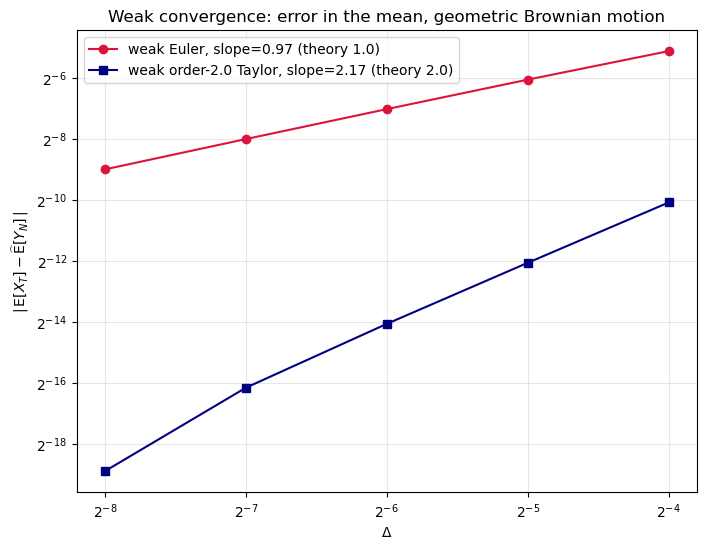


weak Euler measured order:        0.969  (theory: 1.0)
weak order-2.0 Taylor measured order: 2.169  (theory: 2.0)


In [2]:
errs_euler, errs_taylor2 = [], []
for Delta in deltas:
    m_euler = weak_euler_mean(Delta, n_paths, rng)
    m_taylor2 = weak_taylor2_mean(Delta, n_paths, rng)
    errs_euler.append(abs(exact_mean - m_euler))
    errs_taylor2.append(abs(exact_mean - m_taylor2))
    print(f"Delta={Delta:.6f}  weak-Euler mean={m_euler:.8f} (err={errs_euler[-1]:.2e})   "
          f"weak-Taylor2 mean={m_taylor2:.8f} (err={errs_taylor2[-1]:.2e})")

deltas_arr = np.array(deltas)
slope_euler = np.polyfit(np.log(deltas_arr), np.log(errs_euler), 1)[0]
slope_taylor2 = np.polyfit(np.log(deltas_arr), np.log(errs_taylor2), 1)[0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(deltas_arr, errs_euler, 'o-', color='crimson',
        label=rf'weak Euler, slope={slope_euler:.2f} (theory 1.0)')
ax.plot(deltas_arr, errs_taylor2, 's-', color='navy',
        label=rf'weak order-2.0 Taylor, slope={slope_taylor2:.2f} (theory 2.0)')
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$|\,\mathrm{E}[X_T] - \widehat{\mathrm{E}}[Y_N]\,|$')
ax.set_title('Weak convergence: error in the mean, geometric Brownian motion')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.show()

print(f"\nweak Euler measured order:        {slope_euler:.3f}  (theory: 1.0)")
print(f"weak order-2.0 Taylor measured order: {slope_taylor2:.3f}  (theory: 2.0)")


## Conclusion

The weak Euler scheme measures order close to $\beta=1.0$ and the order-2.0 weak Taylor scheme
measures a visibly steeper slope, consistent with $\beta=2.0$ — recovering an entire additional
order of accuracy in the mean by including the deterministic Itô-Taylor correction terms
($bb'$, $ba'\Delta Z_n$, and the second-order drift term) even though no attempt is made to track
the path itself accurately (unlike Milstein, which targets the *same* correction terms' role in
*pathwise*, not just distributional, accuracy). This is the numerical-SDE counterpart of a general
theme in quantitative finance: when the object of interest is $\mathbb E[\text{payoff}]$ rather
than a trajectory, a scheme tailored to weak error can be both simpler (no Lévy-area simulation
needed here — $\Delta Z_n$ is exactly Gaussian) and higher-order than what pathwise accuracy alone
would justify.